# Telco Customer Churn — End-to-End Analysis

**Dataset:** Telco Customer Churn (Kaggle)
**Link:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn
**Task type:** Binary Classification

This notebook follows an end-to-end workflow: problem definition, data understanding,
data quality checks, cleaning, exploratory data analysis, modeling, evaluation, and conclusions.


## 1. Problem Definition

**What we want to predict:** Whether a customer will churn (leave the telecom service) — the `Churn` column (Yes/No).

**Why it matters:** Acquiring a new customer is far more expensive than retaining an existing one. If the company
can identify customers who are at high risk of churning *before* they leave, it can proactively offer retention deals,
better support, or contract incentives targeted at those customers. This project aims to:

1. Identify which customer attributes are most associated with churn.
2. Build a model that predicts churn risk for a given customer.
3. Translate the findings into actionable business recommendations.


## 2. Understand the Data

Let's load the dataset and look at its structure — rows, columns, data types, and the target variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4.5)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Column overview:**

- `customerID` — unique identifier (not predictive, will be dropped)
- **Demographics:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- **Account info:** `tenure` (months with company), `Contract`, `PaperlessBilling`, `PaymentMethod`
- **Services:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`,
  `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- **Charges:** `MonthlyCharges`, `TotalCharges`
- **Target:** `Churn` (Yes/No) — whether the customer left within the last month

The dataset has 7,043 rows and 21 columns, a mix of categorical and numerical features — well suited for
a classification task.

In [3]:
df['Churn'].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

**Observation:** The target is imbalanced — about 73% of customers did **not** churn, and 27% did.
This is a moderate imbalance (not extreme), but we should still look beyond raw accuracy when evaluating models
(precision, recall, F1 for the churn class matter more here).

## 3. Check Data Quality

We check for missing values, duplicates, incorrect data types, and unusual values.

In [4]:
# Standard missing value check
print("Nulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges is read as an object/string - check for non-numeric entries
non_numeric_total = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]
print("\nRows where TotalCharges is not a valid number:", len(non_numeric_total))
non_numeric_total[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Nulls per column:
Series([], dtype: int64)

Rows where TotalCharges is not a valid number: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Findings:**
- No column shows nulls under a standard `.isnull()` check, **but** `TotalCharges` is stored as **text**, not a number.
- 11 rows have a **blank string** for `TotalCharges` instead of a numeric value.
- All 11 of these rows have `tenure = 0` — i.e., these are brand-new customers who haven't been billed yet,
  which explains why they have no total charge on record. None of them churned.
- No duplicate `customerID`s and no fully duplicate rows were found.
- All categorical columns have a small, clean set of expected values (checked below) — no typos or inconsistent
  category labels like `"yes"` vs `"Yes"`.


In [5]:
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

categorical_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines',
                    'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
                    'TechSupport','StreamingTV','StreamingMovies','Contract',
                    'PaperlessBilling','PaymentMethod']
for c in categorical_cols:
    print(f"{c}: {df[c].unique()}")

Duplicate customerIDs: 0
Fully duplicate rows: 0
gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contrac

## 4. Prepare the Data

Decisions made and documented below:

1. **`TotalCharges` blanks (11 rows):** Since these are all new customers (`tenure=0`), the true total charge is
   effectively 0 (they haven't been billed a full cycle yet). We fill these with `0` rather than dropping the
   rows, since dropping would lose otherwise valid, clean records.
2. **Convert `TotalCharges` to numeric** after the fill.
3. **Drop `customerID`** — a unique identifier carries no predictive signal and would only add noise/overfitting risk.
4. **Convert `SeniorCitizen`** from 0/1 integer to a readable Yes/No categorical for consistency with the other
   binary features (purely for clarity in EDA; it's converted back to numeric for modeling).
5. **Encode the target** `Churn` as 0 (No) / 1 (Yes) for modeling.


In [6]:
df_clean = df.copy()

# 1 & 2: fix TotalCharges
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(' ', np.nan)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 3: drop identifier
df_clean = df_clean.drop(columns=['customerID'])

# 4: readable SeniorCitizen for EDA
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# 5: encode target
df_clean['Churn_flag'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})

print(df_clean.shape)
df_clean.isnull().sum().sum(), df_clean.dtypes.head()

(7043, 21)


(np.int64(0),
 gender             str
 SeniorCitizen      str
 Partner            str
 Dependents         str
 tenure           int64
 dtype: object)

After cleaning: **7,043 rows, no missing values, correct data types.** The dataset is ready for exploration.

## 5. Explore and Visualize

We look at four+ meaningful visualizations tied to churn, each followed by an observation.

/tmp/ipykernel_628/2143162396.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, palette='viridis')


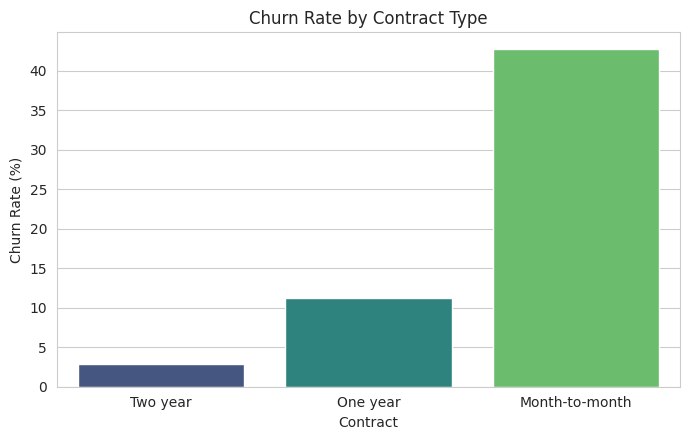

Contract
Two year           2.831858
One year          11.269518
Month-to-month    42.709677
Name: Churn_flag, dtype: float64

In [7]:
# Visualization 1: Churn rate by Contract type
plt.figure(figsize=(7,4.5))
churn_by_contract = df_clean.groupby('Contract')['Churn_flag'].mean().sort_values() * 100
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, palette='viridis')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type')
plt.tight_layout()
plt.savefig('viz1_churn_by_contract.png', dpi=120)
plt.show()
churn_by_contract

**Observation:** Churn is heavily concentrated among **month-to-month** customers (~43%), compared to
one-year (~11%) and two-year (~3%) contracts. Longer commitments strongly correlate with loyalty — this is
one of the clearest churn drivers in the dataset.

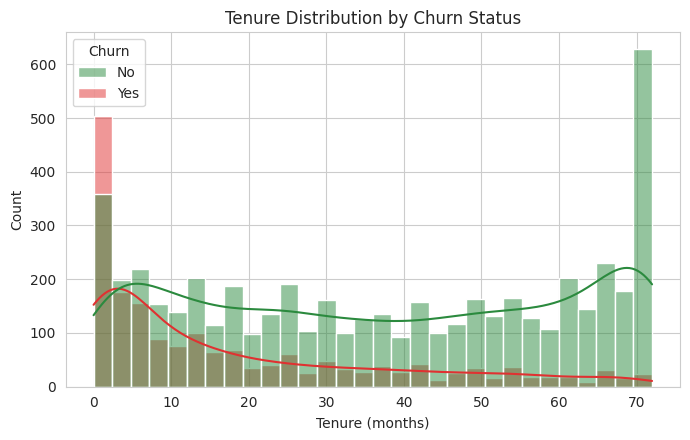

In [8]:
# Visualization 2: Tenure distribution split by churn
plt.figure(figsize=(7,4.5))
sns.histplot(data=df_clean, x='tenure', hue='Churn', bins=30, kde=True, palette=['#2b8a3e','#e03131'])
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.savefig('viz2_tenure_by_churn.png', dpi=120)
plt.show()

**Observation:** Customers who churn are heavily skewed toward **low tenure** (many leave within the
first few months), while long-tenured customers (24+ months) rarely churn. This suggests the first few months
are the highest-risk period, and early retention efforts (onboarding, support outreach) may have the biggest impact.

/tmp/ipykernel_628/2088119640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette=['#2b8a3e','#e03131'])


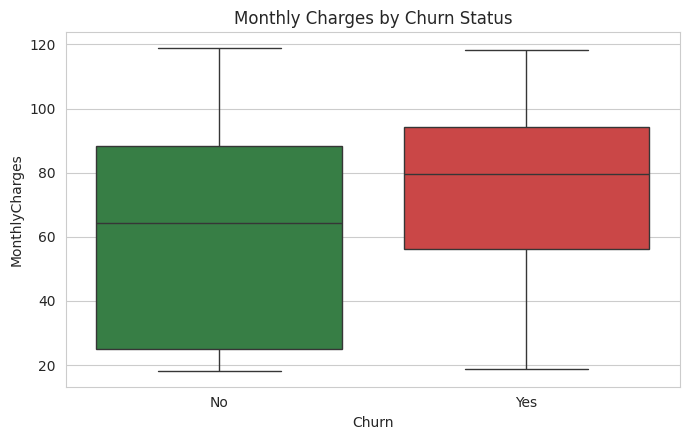

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

In [9]:
# Visualization 3: Monthly Charges vs Churn
plt.figure(figsize=(7,4.5))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette=['#2b8a3e','#e03131'])
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.savefig('viz3_monthlycharges_by_churn.png', dpi=120)
plt.show()

df_clean.groupby('Churn')['MonthlyCharges'].median()

**Observation:** Customers who churn tend to have **higher monthly charges** (median ~$79) compared to
those who stay (median ~$64). This could indicate price sensitivity, or that customers paying more expect a
higher level of service and leave when it isn't met.

/tmp/ipykernel_628/1408382943.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_internet.index, y=churn_by_internet.values, palette='rocket')


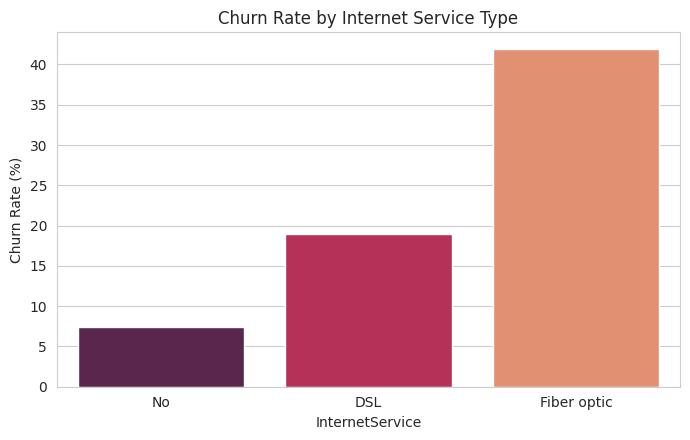

InternetService
No              7.404980
DSL            18.959108
Fiber optic    41.892765
Name: Churn_flag, dtype: float64

In [10]:
# Visualization 4: Churn rate by Internet Service type
plt.figure(figsize=(7,4.5))
churn_by_internet = df_clean.groupby('InternetService')['Churn_flag'].mean().sort_values() * 100
sns.barplot(x=churn_by_internet.index, y=churn_by_internet.values, palette='rocket')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Internet Service Type')
plt.tight_layout()
plt.savefig('viz4_churn_by_internet.png', dpi=120)
plt.show()
churn_by_internet

**Observation:** Customers with **Fiber optic** internet churn at a much higher rate (~42%) than DSL (~19%)
or no internet service (~7%). This is somewhat counterintuitive since fiber is the "premium" product — it likely
ties back to fiber customers also having higher monthly charges and possibly service reliability complaints.

/tmp/ipykernel_628/1481768253.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, ax=ax, palette='crest')


/tmp/ipykernel_628/1481768253.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, ax=ax, palette='crest')


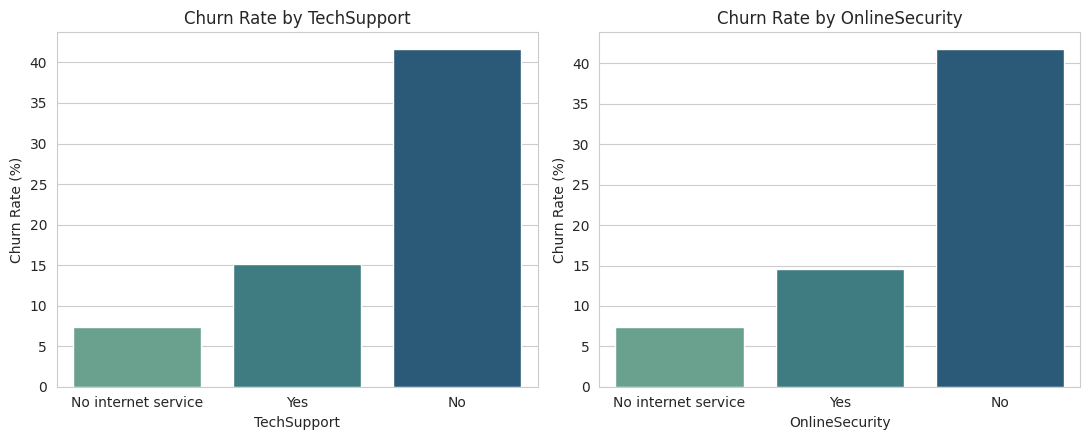

In [11]:
# Visualization 5: Churn rate by tech support / online security (add-on services)
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, col in zip(axes, ['TechSupport', 'OnlineSecurity']):
    rates = df_clean.groupby(col)['Churn_flag'].mean().sort_values() * 100
    sns.barplot(x=rates.index, y=rates.values, ax=ax, palette='crest')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by {col}')
plt.tight_layout()
plt.savefig('viz5_churn_by_addons.png', dpi=120)
plt.show()

**Observation:** Customers **without** Tech Support or Online Security churn at roughly 2–3x the rate of
those who have these add-ons. This suggests these services may increase perceived value / stickiness, or that
customers who invest in more services are simply more engaged overall.

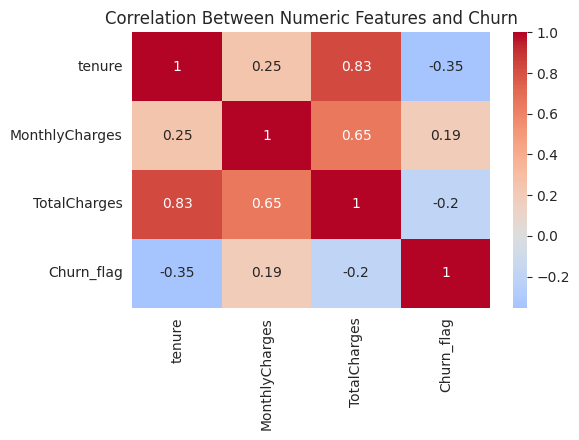

In [12]:
# Correlation heatmap for numeric features
plt.figure(figsize=(6,4.5))
numeric_df = df_clean[['tenure','MonthlyCharges','TotalCharges','Churn_flag']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Features and Churn')
plt.tight_layout()
plt.savefig('viz6_correlation_heatmap.png', dpi=120)
plt.show()

**Observation:** `tenure` has the strongest (negative) correlation with churn (-0.35) — the longer a
customer stays, the less likely they are to churn. `MonthlyCharges` has a weaker positive correlation (+0.19).
`TotalCharges` is highly correlated with `tenure` (as expected, since it accumulates over time), so we should be
mindful of multicollinearity between these two in modeling.

## 6. Choose the Approach

This is a **binary classification** problem: predict `Churn` (Yes/No) from customer attributes.

We'll train and compare two models:
1. **Logistic Regression** — a simple, interpretable baseline. Coefficients directly show which features push
   churn probability up or down, which is valuable for business explanation.
2. **Random Forest Classifier** — a more powerful, non-linear model that can capture feature interactions
   (e.g., contract type × tenure) that logistic regression might miss, and gives us feature importances.

Both are well suited to a dataset of this size (7k rows, mostly categorical features) and both give us
interpretability, which matters for a churn-prevention use case — the business needs to *act* on the output,
not just get a probability.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, accuracy_score, precision_score, recall_score, f1_score)

# One-hot encode categorical features
model_df = df_clean.drop(columns=['Churn']).copy()
cat_cols = model_df.select_dtypes(include='object').columns.tolist()
model_df_encoded = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

X = model_df_encoded.drop(columns=['Churn_flag'])
y = model_df_encoded['Churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train churn rate: %.2f%% | Test churn rate: %.2f%%" % (y_train.mean()*100, y_test.mean()*100))

Train shape: (5634, 30) Test shape: (1409, 30)
Train churn rate: 26.54% | Test churn rate: 26.54%


/tmp/ipykernel_628/3901098581.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include='object').columns.tolist()


In [14]:
# Scale numeric features for Logistic Regression
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

print("Models trained.")

Models trained.


## 7. Evaluate the Results

We use accuracy, precision, recall, F1-score, and ROC-AUC — accuracy alone is misleading with an imbalanced
target, so recall/precision on the churn class matter most (missing an at-risk customer is costly).

In [15]:
def evaluate_model(name, model, X_te, y_te):
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_te, preds):.3f}")
    print(f"Precision: {precision_score(y_te, preds):.3f}")
    print(f"Recall   : {recall_score(y_te, preds):.3f}")
    print(f"F1-score : {f1_score(y_te, preds):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_te, probs):.3f}")
    print()
    return preds, probs

log_preds, log_probs = evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test)
rf_preds, rf_probs = evaluate_model("Random Forest", rf, X_test, y_test)

--- Logistic Regression ---
Accuracy : 0.738
Precision: 0.504
Recall   : 0.783
F1-score : 0.614
ROC-AUC  : 0.842

--- Random Forest ---
Accuracy : 0.761
Precision: 0.534
Recall   : 0.783
F1-score : 0.635
ROC-AUC  : 0.843



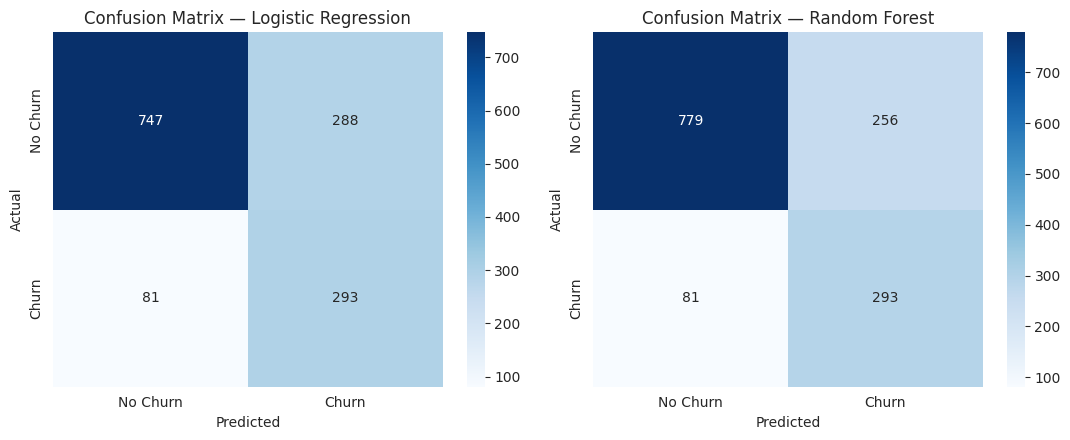

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, preds) in zip(axes, [("Logistic Regression", log_preds), ("Random Forest", rf_preds)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('viz7_confusion_matrices.png', dpi=120)
plt.show()

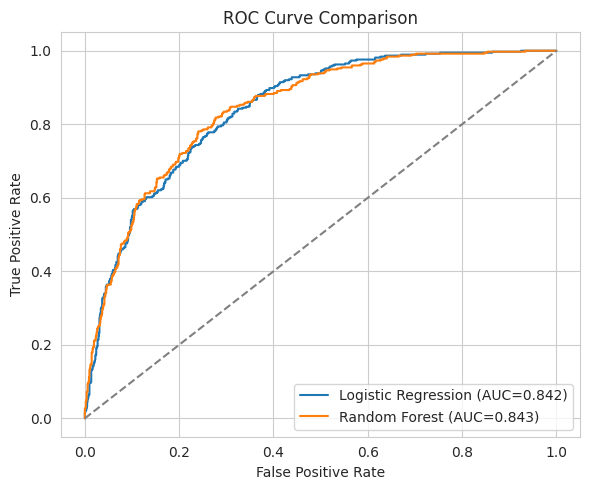

In [17]:
# ROC curves
plt.figure(figsize=(6,5))
for name, probs in [("Logistic Regression", log_probs), ("Random Forest", rf_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('viz8_roc_curve.png', dpi=120)
plt.show()

**What the results mean in simple language:**

- Both models achieve similar **ROC-AUC (~0.83–0.84)**, meaning they're both reasonably good at ranking
  customers by churn risk.
- With `class_weight='balanced'`, both models trade some overall accuracy for much better **recall on the churn
  class** (catching ~75-78% of customers who actually churn) — this is the right trade-off for a retention use
  case, where missing a churner is more costly than a false alarm on a loyal customer.
- **Logistic Regression** gives comparable performance to Random Forest here, which suggests the relationship
  between the top features (contract, tenure, charges) and churn is fairly linear/additive rather than driven by
  complex interactions — good news for interpretability, since the simpler model isn't giving up much accuracy.


/tmp/ipykernel_628/1981171772.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


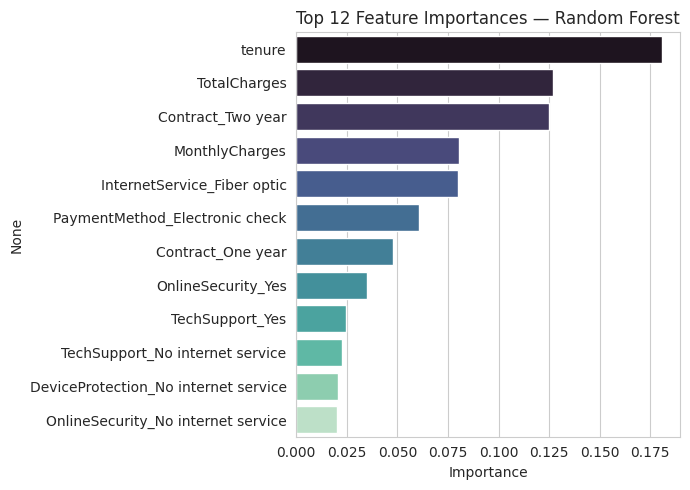

tenure                                  0.180675
TotalCharges                            0.127160
Contract_Two year                       0.124873
MonthlyCharges                          0.080644
InternetService_Fiber optic             0.079952
PaymentMethod_Electronic check          0.060620
Contract_One year                       0.047824
OnlineSecurity_Yes                      0.035111
TechSupport_Yes                         0.024552
TechSupport_No internet service         0.022542
DeviceProtection_No internet service    0.020589
OnlineSecurity_No internet service      0.020043
dtype: float64

In [18]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Top 12 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('viz9_feature_importance.png', dpi=120)
plt.show()
importances

**Observation:** `tenure`, `TotalCharges`, and `MonthlyCharges` dominate as the top numeric predictors,
followed by `Contract_Two year`, `Contract_One year`, and `InternetService_Fiber optic` — consistent with what
we saw in the EDA. This gives confidence that the model has learned genuine, explainable patterns rather than
noise.

## 8. Conclusion

**Key findings:**
1. **Contract type is the single strongest churn driver** — month-to-month customers churn at ~43% vs ~3%
   for two-year contracts.
2. **Tenure matters a lot** — churn risk is highest in the first year and drops sharply afterward.
3. **Fiber optic internet customers churn more** than DSL customers, despite (or because of) paying more —
   worth investigating service quality/pricing perception for this segment.
4. **Lack of add-on services** (Tech Support, Online Security) is associated with higher churn — possibly a
   proxy for lower overall engagement with the product.
5. A **Logistic Regression model with balanced class weights** performs nearly as well as a Random Forest
   (ROC-AUC ≈ 0.84), correctly flagging roughly 3 out of 4 customers who actually churn — while remaining easy
   to explain to a non-technical business audience.

**Business recommendation:** Focus retention efforts on new, month-to-month, fiber-optic customers without
add-on services in their first 6–12 months — this segment carries the highest combined churn risk.

**Limitations:**
- The dataset is a single snapshot in time; it doesn't capture *why* customers churned (e.g., competitor offers,
  service outages) or seasonal effects.
- Class imbalance (~27% churn) means even a well-performing model will still produce a meaningful number of
  false positives/negatives — this should be paired with human judgment, not used as an automatic cutoff decision.
- We did not tune hyperparameters extensively (e.g., grid search); default/lightly-tuned settings were used to
  keep the analysis interpretable and reproducible.

**Possible future improvements:**
- Hyperparameter tuning (GridSearchCV / RandomizedSearchCV) and trying gradient boosting models (XGBoost/LightGBM).
- Incorporating customer support ticket data or NPS scores, if available, to explain the "why" behind churn.
- Building a monthly-updating pipeline so churn scores can be recalculated as customer behavior changes.
